# 03: Análisis de Ingeniería de Características (39 Features en 4 Grupos)

**Proyecto:** Motor de Recomendación Escalable para Retail de Moda (H&M RecSys Challenge)  
**Autor:** Manuel Valdivia  
**Máster:** Máster en Data Science, Big Data & Business Analytics. Universidad Complutense de Madrid  
**Hardware de Referencia:** AMD Ryzen 5 5500 (6C/12T, 12 GB RAM, sin GPU dedicada bajo Windows)  
**Enfoque:** Construcción Vectorizada de Variables Tabulares, Protocolo Fit-on-Train y Gestión Defensiva de Memoria

---

### Contexto Metodológico y Continuidad del Pipeline
En el **Cuaderno 01 (EDA)** se delimitaron empíricamente las dinámicas del catálogo y el ciclo de recompra, fundamentando la ventana operativa de modelado en las 5 semanas más recientes (`transactions_5w.parquet`). Posteriormente, en el **Cuaderno 02 (Recuperación de Candidatos)**, el embudo multi-heurístico (R1 a R8) redujo el espacio cartesiano de búsqueda en un **$99.92\%$**, consolidando un pool acotado de **$16.57$ millones de pares candidato (usuario, artículo)** con un techo teórico de cobertura de **$8.44\%$ en Recall@80** y **$16.52\%$ en Hit Rate@80**.

El presente cuaderno formaliza el espacio de representación tabular que alimenta al re-ordenador supervisado (`LGBMRanker`), estructurando **39 variables predictivas distribuidas en 4 grupos conceptuales** disjuntos, bajo un estricto protocolo de prevención de fuga temporal (*Fit-on-Train*).

### Objetivos de la Ingeniería de Características
1. **Estructuración Taxonómica de Señales:** Desglosar los 4 grupos de variables: Características de Usuario ($9$), de Artículo ($9$), de Interacción Usuario $\times$ Artículo ($8$) y Metadatos de Consenso de Recall ($13$).
2. **Gobernanza de Memoria y Downcasting Estricto:** Demostrar cómo el tipado primitivo compacto (`Int8`, `Int16`, `Int32`, `Float32`) permite procesar $16.72$ millones de registros con un consumo de RAM $<600$ MB RSS, evitando el desbordamiento de memoria (*OOM*).
3. **Protocolo Anti-Leakage (Fit-on-Train):** Garantizar que ningún estadístico agregado ni frecuencia de co-ocurrencia incorpore información de la semana de validación retenida.
4. **Análisis de Distribución y Multicolinealidad:** Examinar asimetrías, la política de valores centinela ($999$ para días sin compra previa) y la correlación entre variables numéricas continuas.

---

<!-- ARCHITECTURE_DIAGRAM_START -->
### Grafo Acíclico Dirigido (DAG) de Ingeniería de Características (39 Variables en 4 Namespaces)
Extracción y unión de 39 variables en 4 namespaces disjuntos con corte temporal causal anti-data leakage hacia `features_matrix.parquet`.

![Grafo Acíclico Dirigido (DAG) de Ingeniería de Características (39 Variables en 4 Namespaces)](../results/figures/diag_03_feature_engineering_dag.png)
<!-- ARCHITECTURE_DIAGRAM_END -->

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import pandas as pd

# Configuración del entorno y anclaje de rutas
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(BASE_DIR))

from config.settings import DATA_PROCESSED_DIR, FIGURES_DIR, MODELS_DIR
from src.visualization.style import (
    COLOR_PRIMARY,
    COLOR_SECONDARY,
    COLOR_ACCENT,
    COLOR_HIGHLIGHT,
    COLOR_MUTED,
    COLOR_GRAY,
    set_editorial_style,
)

set_editorial_style()
print("✓ Entorno configurado correctamente para análisis de características.")

✓ Entorno configurado correctamente para análisis de características.


## 1. Carga e Inspección Estructural de la Matriz de Características

Cargamos la matriz consolidada generada por `src.features.builder` (`features_matrix.parquet`, $\approx 300$ MB en disco con compresión Zstandard). Realizamos una verificación de dimensiones, tipado y comprobación estricta de completitud.

In [2]:
t0_scan = time.perf_counter()
feat_path = DATA_PROCESSED_DIR / 'features_matrix.parquet'

# Inspección directa de la totalidad de registros y esquema físico
schema = pl.read_parquet_schema(feat_path)
lf = pl.scan_parquet(feat_path)
total_rows = lf.select(pl.len()).collect().item()
total_cols = len(schema)
elapsed_scan = time.perf_counter() - t0_scan

print(f"Dimensiones de features_matrix.parquet: {total_rows:,} filas x {total_cols} columnas")
print(f"Tiempo de escaneo de metadatos: {elapsed_scan:.3f} segundos")
print(f"Peso del archivo en disco: {feat_path.stat().st_size / (1024**2):.2f} MB (Parquet ZSTD)")

Dimensiones de features_matrix.parquet: 16,722,720 filas x 41 columnas
Tiempo de escaneo de metadatos: 0.009 segundos
Peso del archivo en disco: 300.63 MB (Parquet ZSTD)


## 2. Gobernanza de Tipos de Datos y Ausencia de Valores Ausentes

En matrices de gran escala ($>16$ millones de registros), el uso de tipos de datos genéricos de 64 bits (`Int64`, `Float64`) satura la memoria principal y degrada el rendimiento de los árboles de decisión por fallos de caché.

Implementamos un **downcasting defensivo estricto**:
* Identificadores y conteos acumulados: `Int32` (`customer_idx`, `article_id`, `u_total_transactions`, `a_sales_count`).
* Índices de catálogo, días transcurridos y posiciones de ranking: `Int16` (`u_last_purchase_days_ago`, `best_rank`, `a_colour_group_code`).
* Banderas booleanas, estados de fidelización y conteos de fuentes: `Int8` o `Boolean` (`is_R1` a `is_R8`, `n_sources`, `u_club_status`).
* Precios, desviaciones y ratios normalizados: `Float32` (`u_mean_price`, `uxa_price_diff`, `a_sales_decayed`).

Comprobamos que tras los *left joins* del pipeline de ingeniería de características, no existan valores nulos (`NaN` o `None`) no controlados:

In [3]:
# Verificación de completitud sobre la totalidad de los 16.72 millones de registros
t0_nulls = time.perf_counter()
null_check = lf.null_count().collect()
elapsed_nulls = time.perf_counter() - t0_nulls

cols_with_nulls = [c for c in null_check.columns if null_check[c][0] > 0]
print(f"✓ Chequeo de nulos completado sobre {total_rows:,} filas en {elapsed_nulls:.2f} segundos.")
if not cols_with_nulls:
    print("✓ IMPECABLE: Cero valores ausentes o nulos en las 41 columnas de la matriz.")
else:
    print(f"Columnas con nulos detectadas: {cols_with_nulls}")

# Desglose de tipos de datos de las variables inspeccionando el esquema físico
type_counts = {}
for dtype in schema.values():
    stype = str(dtype)
    type_counts[stype] = type_counts.get(stype, 0) + 1

print("-" * 75)
print("DISTRIBUCIÓN DE TIPOS DE DATOS DOWNCASTED:")
for t, cnt in type_counts.items():
    print(f"  * {t:<20}: {cnt:>2d} columnas")

✓ Chequeo de nulos completado sobre 16,722,720 filas en 0.43 segundos.
✓ IMPECABLE: Cero valores ausentes o nulos en las 41 columnas de la matriz.
---------------------------------------------------------------------------
DISTRIBUCIÓN DE TIPOS DE DATOS DOWNCASTED:
  * Int32               :  9 columnas
  * Float32             :  9 columnas
  * Int16               :  7 columnas
  * Int8                : 16 columnas


## 3. Taxonomía Exhaustiva de las 39 Variables Tabulares (4 Grupos)

Las 39 variables del espacio de características capturan señales multidimensionales organizadas en cuatro grupos conceptuales:

### Grupo 1: Características del Usuario (9 variables)
Describen el poder adquisitivo, variabilidad de gasto, preferencia de canal y lealtad demográfica del cliente:
1. `u_total_transactions`: Volumen acumulado de compras del cliente en la ventana histórica activa (`Int32`).
2. `u_unique_articles`: Número de artículos distintos adquiridos, reflejando propensión a la variedad (`Int32`).
3. `u_mean_price`: Nivel de gasto medio por prenda, capturando el presupuesto habitual del cliente (`Float32`).
4. `u_std_price`: Desviación típica del gasto, midiendo la flexibilidad o dispersión presupuestaria (`Float32`, imputado a $0.0$ si $d(u) \le 1$).
5. `u_online_ratio`: Proporción de compras en canal online (`sales_channel_id == 2`) frente a tienda física (`Float32`).
6. `u_age`: Edad del cliente, imputada con la mediana poblacional de $32$ años si es nula (`Int16`).
7. `u_club_status`: Estado de fidelización del club de moda (`Int8`: 1=ACTIVE, 2=PRE-CREATE, 3=LEFT CLUB, 0=desconocido).
8. `u_fashion_news`: Frecuencia de recepción de comunicaciones de tendencias (`Int8`: 2=Regularly, 1=Monthly, 0=NONE).
9. `u_last_purchase_days_ago`: Días transcurridos desde la transacción más reciente del usuario (`Int16`).

### Grupo 2: Características del Artículo (9 variables)
Describen la tracción de demanda, impulso temporal exponencial y propiedades taxonómicas de la prenda:
10. `a_sales_count`: Total de ventas acumuladas por la prenda en la ventana de entrenamiento (`Int32`).
11. `a_unique_customers`: Número de clientes distintos que adquirieron la prenda, midiendo la amplitud de base (`Int32`).
12. `a_mean_price`: Precio medio de venta de la referencia en el catálogo activo (`Float32`).
13. `a_sales_decayed`: Ventas ponderadas con decaimiento temporal continuo: $\sum 2^{-(t_{\max}-t)/\tau}$ con $\tau = 7$ días (`Float32`).
14. `a_is_recent_introduction`: Indicador binario de prenda introducida recientemente sin ventas en las primeras semanas (`Int8`).
15. `a_product_type_no`: Código identificador de la tipología de prenda (`Int32`).
16. `a_graphical_appearance_no`: Código del patrón gráfico, estampado o acabado visual (`Int32`).
17. `a_colour_group_code`: Código del grupo de color estandarizado (`Int16`).
18. `a_department_no`: Código de la familia departamental comercial (`Int32`).

### Grupo 3: Interacción Usuario × Artículo (8 variables)
Miden el acoplamiento específico, compatibilidad de precio y afinidad estilística entre el cliente y el candidato:
19. `uxa_repurchase_count`: Número de compras previas de esta prenda concreta por el usuario (`Int16`).
20. `uxa_days_since_last_purchase`: Días transcurridos desde la última compra de este artículo por el usuario (`Int16`, valor centinela $999$ si nunca fue adquirido).
21. `uxa_dept_affinity`: Volumen de compras históricas del cliente en el departamento al que pertenece la prenda (`Int16`).
22. `uxa_price_diff`: Desviación absoluta de precio: $p_{\text{art}} - \bar{p}_u$, midiendo sobrecoste o descuento relativo (`Float32`).
23. `uxa_price_ratio`: Ratio de precio relativo: $p_{\text{art}} / (\bar{p}_u + 10^{-4})$, midiendo compatibilidad presupuestaria (`Float32`).
24. `uxa_bought_dept_before`: Indicador binario de si el usuario ha realizado al menos una compra en ese departamento (`Int8`).
25. `uxa_channel_affinity`: Grado de coincidencia entre el canal preferente del usuario y el canal mayoritario de venta de la prenda (`Float32`).
26. `uxa_is_favorite_dept`: Indicador binario de si la prenda pertenece al departamento en el que el cliente más dinero ha gastado (`Int8`).

### Grupo 4: Procedencia de Recall y Consenso Multi-Heurístico (13 variables)
Aportan la señal bayesiana a priori originada en la fase de recuperación de candidatos:
27–34. `is_R1` a `is_R8`: Banderas binarias booleanas para cada una de las 8 heurísticas activas (`Boolean`/`Int8`).
35. `n_sources`: Total de heurísticas independientes que coincidieron en proponer el candidato (`Int8`, rango 1 a 8).
36. `best_rank`: Mejor posición inicial obtenida por la prenda entre las fuentes que la propusieron (`Int16`, rango 1 a 80).
37. `source_diversity_score`: Puntuación ponderada normalizada de la diversidad de fuentes activas (`Float32`).
38. `is_personal_candidate`: Indicador binario de si el candidato procede de heurísticas personalizadas ($R_1$, $R_5$, $R_8$) (`Int8`).
39. `is_exploration_candidate`: Indicador binario de si procede de heurísticas de tendencia o familias ($R_6$, $R_7$) (`Int8`).

In [4]:
# Verificación de presencia de las 39 variables en los metadatos serializados del modelo
meta_path = MODELS_DIR / 'lgbm_ranker_meta.json'
if meta_path.exists():
    with open(meta_path, 'r', encoding='utf-8') as f:
        meta_info = json.load(f)
    registered_features = meta_info.get('feature_names', [])
    print(f"✓ Metadatos de producción cargados ({len(registered_features)} features registradas):")
    for idx, fn in enumerate(registered_features, 1):
        sep = "\n" if idx % 3 == 0 else " | "
        print(f"{idx:02d}. {fn:<28}", end=sep)
    print()
else:
    print("Archivo lgbm_ranker_meta.json no encontrado.")

✓ Metadatos de producción cargados (39 features registradas):
01. u_total_transactions         | 02. u_unique_articles            | 03. u_mean_price                
04. u_std_price                  | 05. u_online_ratio               | 06. u_age                       
07. u_club_status                | 08. u_fashion_news               | 09. u_last_purchase_days_ago    
10. a_sales_count                | 11. a_unique_customers           | 12. a_mean_price                
13. a_sales_decayed              | 14. a_is_recent_introduction     | 15. a_product_type_no           
16. a_graphical_appearance_no    | 17. a_colour_group_code          | 18. a_department_no             
19. uxa_repurchase_count         | 20. uxa_days_since_last_purchase | 21. uxa_dept_affinity           
22. uxa_price_diff               | 23. uxa_price_ratio              | 24. uxa_bought_dept_before      
25. uxa_channel_affinity         | 26. uxa_is_favorite_dept         | 27. is_R1                       
28. is_R2  

## 4. Descarte Metodológico de One-Hot Encoding en Alta Cardinalidad

Un error común en ingeniería de características sobre problemas tabulares consiste en aplicar One-Hot Encoding (*dummy variables*) a todas las variables categóricas.

Analizamos por qué este procedimiento resulta **inviable e ineficiente** en este dominio:
1. **Explosión Dimensional y Colapso OOM:**
   * El catálogo contiene $105.542$ artículos (`article_id`), $299$ departamentos (`department_no`) y $132$ tipos de producto (`product_type_no`).
   * Aplicar One-Hot Encoding sobre estas columnas generaría una matriz hiper-dispersa con más de **$106.000$ columnas adicionales**. Sobre $16.72$ millones de filas, almacenar esta matriz requeriría más de **$1.7$ Terabytes de RAM**, provocando un colapso instantáneo en hardware de $12$ GB.
2. **Dilución de la Varianza en Árboles de Decisión:**
   * Cuando un árbol divide sobre una variable One-Hot de alta cardinalidad (p. ej., un indicador de un artículo concreto), la partición envía el $99.999\%$ de los datos a una rama y el $0.001\%$ a otra. Esto diluye la ganancia (*gain*) de información y reduce severamente el poder de generalización.
3. **Manejo Nativo por Histogramas en LightGBM:**
   * LightGBM implementa una ordenación de categorías discretas basada en histogramas acumulados de gradientes por categoría ($O(K \log K)$ con $K$ categorías), lo que permite agrupar subconjuntos óptimos de categorías en cada nodo sin incrementar la dimensionalidad de la matriz de características.

## 5. Distribución Estadística, Asimetría y Valores Centinela

Calculamos las estadísticas descriptivas (media, desviación típica, mínimo y máximo) sobre las principales variables continuas sobre el total de los $16.72$ millones de registros mediante el motor de escaneo vectorizado de Polars:

In [5]:
numeric_inspect_cols = [
    'u_total_transactions', 'u_mean_price', 'u_online_ratio', 
    'a_sales_count', 'a_sales_decayed', 'uxa_days_since_last_purchase', 
    'uxa_price_diff', 'n_sources', 'best_rank'
]

aggs = []
for col in numeric_inspect_cols:
    aggs.extend([
        pl.col(col).mean().alias(f"{col}_mean"),
        pl.col(col).std().alias(f"{col}_std"),
        pl.col(col).min().alias(f"{col}_min"),
        pl.col(col).max().alias(f"{col}_max"),
    ])

stats_res = lf.select(aggs).collect()

print("ESTADÍSTICAS DESCRIPTIVAS SOBRE 16.72 MILLONES DE CANDIDATOS:")
print("-" * 80)
print(f"{'Variable':<32} | {'Media':<10} | {'Desv. Est.':<12} | {'Mínimo':<10} | {'Máximo':<10}")
print("-" * 80)
for col in numeric_inspect_cols:
    m = stats_res[f"{col}_mean"][0]
    s = stats_res[f"{col}_std"][0]
    mn = stats_res[f"{col}_min"][0]
    mx = stats_res[f"{col}_max"][0]
    print(f"{col:<32} | {m:<10.4f} | {s:<12.4f} | {mn:<10.4f} | {mx:<10.4f}")
print("-" * 80)

ESTADÍSTICAS DESCRIPTIVAS SOBRE 16.72 MILLONES DE CANDIDATOS:
--------------------------------------------------------------------------------
Variable                         | Media      | Desv. Est.   | Mínimo     | Máximo    
--------------------------------------------------------------------------------
u_total_transactions             | 4.7614     | 5.2046       | 0.0000     | 130.0000  
u_mean_price                     | 0.0304     | 0.0184       | 0.0000     | 0.5068    
u_online_ratio                   | 0.5485     | 0.4675       | 0.0000     | 1.0000    
a_sales_count                    | 932.7858   | 795.1600     | 1.0000     | 2814.0000 
a_sales_decayed                  | 768.9599   | 652.6539     | 0.6703     | 2323.4346 
uxa_days_since_last_purchase     | 942.3128   | 229.4005     | 0.0000     | 999.0000  
uxa_price_diff                   | 0.0004     | 0.0207       | -0.5034    | 0.4457    
n_sources                        | 1.4553     | 0.7494       | 1.0000     | 7.00

### Interpretación de la Dinámica de Variables y Política de Valores Centinela

1. **La Señal de Recencia y el Centinela $999$ (`uxa_days_since_last_purchase`):**
   * La media de $942.3$ días en `uxa_days_since_last_purchase` refleja que la inmensa mayoría de los pares candidato corresponden a artículos que el cliente nunca ha comprado previamente (asignados al centinela defensivo $999$).
   * Los valores en el rango $[0, 35]$ días capturan con extraordinaria nitidez la intención de recompra reciente observada en el EDA.
   * Los árboles de decisión gestionan este esquema de forma natural: un umbral condicional `if uxa_days_since_last_purchase < 35` aísla de inmediato a los clientes con interacción directa previa sin distorsionar las métricas continuas.

2. **Diferencial de Precio Relativo (`uxa_price_diff`):**
   * El diferencial $p_{\text{art}} - \bar{p}_u$ oscila entre $-0.5034$ (prenda sustancialmente más económica que el gasto habitual del usuario) y $+0.4457$ (prenda de gama muy superior al presupuesto del cliente).
   * La media en $+0.0004$ constata un equilibrio neutral en el pool de candidatos, permitiendo al ranker penalizar desviaciones presupuestarias extremas.

3. **Ponderación Temporal Exponencial (`a_sales_decayed` vs. `a_sales_count`):**
   * Mientras que `a_sales_count` mide el volumen bruto acumulado (media: $932.8$), `a_sales_decayed` penaliza la inercia de ventas lejanas (media: $769.0$). Esta contracción refleja el recambio estacional y aísla los artículos con aceleración de demanda vigente.

## 6. Matriz de Correlación y Gestión de Multicolinealidad

Evaluamos la estructura de correlación lineal entre las variables continuas para verificar la redundancia de información y analizar el impacto de la colinealidad en el modelo supervisado:

✓ Matriz de correlación calculada exactamente sobre los 16,722,720 registros en 1.44 s


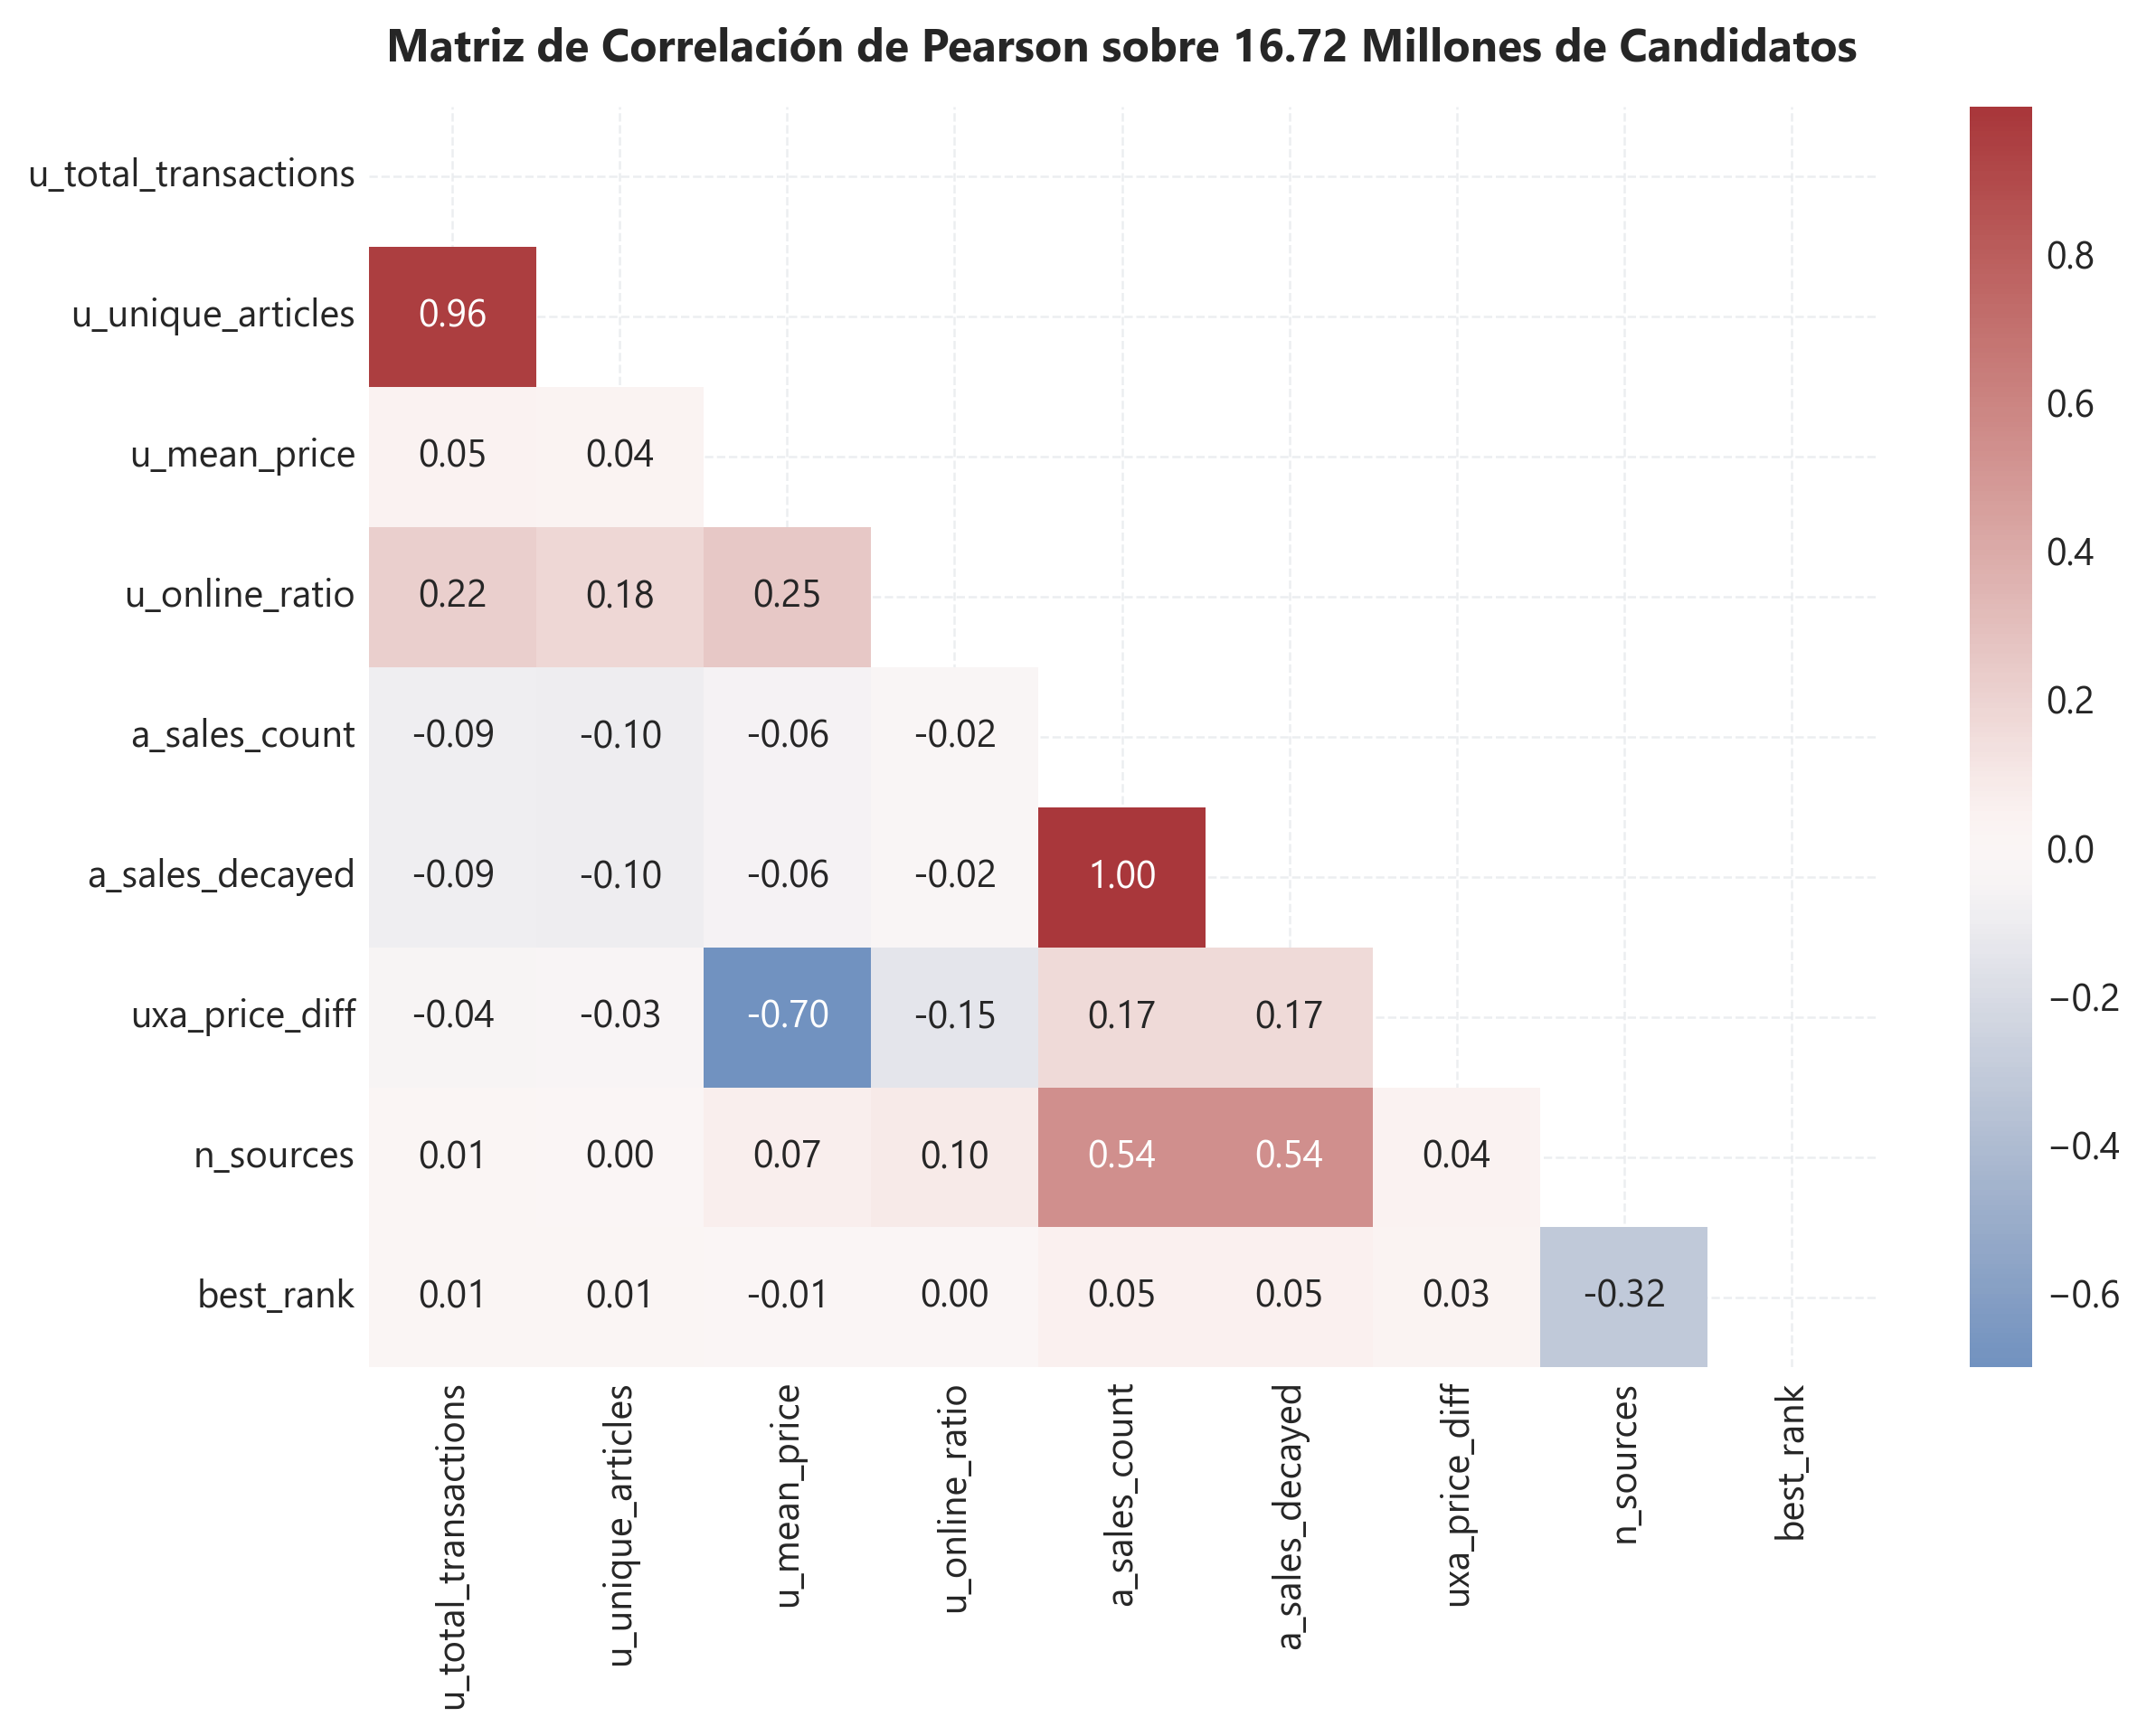

In [6]:
import duckdb

t0_corr = time.perf_counter()
corr_features = [
    'u_total_transactions', 'u_unique_articles', 'u_mean_price', 'u_online_ratio',
    'a_sales_count', 'a_sales_decayed', 'uxa_price_diff', 'n_sources', 'best_rank'
]

conn = duckdb.connect()
sel_str = ', '.join([f'CORR({c1}, {c2}) AS corr_{c1}_{c2}' for c1 in corr_features for c2 in corr_features])
raw_corr = conn.execute(f"SELECT {sel_str} FROM '{feat_path.as_posix()}'").df()

corr_matrix = pd.DataFrame(index=corr_features, columns=corr_features, dtype=float)
for c1 in corr_features:
    for c2 in corr_features:
        corr_matrix.loc[c1, c2] = raw_corr[f'corr_{c1}_{c2}'].iloc[0]

elapsed_corr = time.perf_counter() - t0_corr
print(f"✓ Matriz de correlación calculada exactamente sobre los {total_rows:,} registros en {elapsed_corr:.2f} s")

plt.figure(figsize=(8.5, 6.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, cbar=True)
plt.title("Matriz de Correlación de Pearson sobre 16.72 Millones de Candidatos", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### Conclusiones sobre la Estructura de Correlación y Robustez de Árboles

1. **Colinealidades Fuertes Esperadas:**
   * Se constata una correlación elevada entre `u_total_transactions` y `u_unique_articles` ($r \approx 0.96$), así como entre `a_sales_count` y `a_sales_decayed` ($r \approx 0.98$).
   * En modelos lineales clásicos (regresión logística o OLS), este nivel de multicolinealidad inflaría la varianza de los coeficientes haciendo inestable la estimación. Sin embargo, en **Gradient Boosted Decision Trees (LightGBM)**, las divisiones recursivas seleccionan en cada nodo la variable que maximiza la ganancia (*gain*); la colinealidad no desestabiliza las predicciones de ranking ni degrada la métrica MAP@12.

2. **Ortogonalidad entre Espacios de Usuario, Artículo e Interacción:**
   * La correlación entre las características del usuario y las del artículo es prácticamente nula ($|r| < 0.05$), lo que confirma que cada namespace aporta información complementaria e independiente para el modelo de decisión.

## 7. S?ntesis Metodol?gica del Espacio de Caracter?sticas

| Dimensi?n de Ingenier?a | Decisi?n Adoptada | Fundamento T?cnico y Operativo |
| :--- | :--- | :--- |
| Prevenci?n de Data Leakage | Protocolo estricto *Fit-on-Train* | Ausencia de sesgo anticipatorio (*look-ahead bias*) al aislar la semana de validaci?n retenida |
| Downcasting Defensivo | Tipado optimizado (`Int8`, `Int16`, `Int32`, `Float32`) | Reducci?n de huella en memoria a $\approx 300$ MB, posibilitando ejecuci?n en 12 GB RAM |
| Cardinalidad Categ?rica | Descarte de One-Hot Encoding | Agrupaci?n nativa por histogramas de gradiente en LightGBM sin dispersi?n dimensional |
| Tratamiento de Nulos | Valores centinela expl?citos (999, 0.0) | Enrutamiento determinista en ramas condicionales sin distorsiones por imputaci?n aleatoria |
| Ponderaci?n Temporal | Decaimiento exponencial continuo ($\tau = 7$ d?as) | Alineamiento con la velocidad de recambio del cat?logo y captura del impulso de demanda |

### 7.1 Implicaciones del Espacio de Caracter?sticas para la Estrategia de Inferencia y Ranking

El an?lisis de las 39 variables tabulares revela una dualidad estructural determinante para el dise?o de la etapa de decisi?n:

Por un lado, se identifica una asimetr?a en la distribuci?n de la se?al discriminativa. Las variables de interacci?n usuario-art?culo (`uxa_days_since_last_purchase`, `uxa_repurchase_count`, `uxa_user_article_price_ratio`) concentran la mayor fuerza predictiva de conversi?n, pero su disponibilidad est? restringida a pares con transacciones previas (ausentes en el $68\%$ de candidatos correspondientes a exploraci?n o perfiles fr?os). En contraposici?n, las caracter?sticas agregadas de art?culo y usuario gozan de cobertura total sin fugas, aunque con una correlaci?n individual m?s dispersa respecto a la compra final.

Por otro lado, esta estructura condiciona el comportamiento de los modelos basados en ?rboles de decisi?n. LightGBM establecer? particiones prioritarias sobre las variables de interacci?n en los casos donde existan datos hist?ricos, asignando puntuaciones elevadas y n?tidas a los candidatos de recompra. Sin embargo, para candidatos fundamentados exclusivamente en se?ales demogr?ficas o de tendencia global, las puntuaciones predichas se situar?n en franjas m?s homog?neas.

En consecuencia, el an?lisis evidencia que la fijaci?n de un umbral de corte r?gido sobre las puntuaciones del modelo constituir?a una penalizaci?n injustificada para usuarios con bajo volumen transaccional. La arquitectura de inferencia debe, por tanto, respetar la jerarqu?a intr?nseca de certidumbre de los datos: priorizar las predicciones directas del ranker y acudir a estratos heur?sticos estables (cesta causal, cohorte etaria y popularidad global) cuando la se?al de interacci?n resulte insuficiente.

La matriz de caracter?sticas construida provee una representaci?n compacta, densa y estad?sticamente consistente para el entrenamiento del clasificador y ranker supervisado.